In [58]:
import os
from pathlib import Path
from typing import Annotated, Literal
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool
from langchain_ollama import ChatOllama
from langchain_tavily import TavilySearch
from langgraph.graph import END, START, StateGraph, MessagesState
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from typing_extensions import TypedDict
from langgraph.checkpoint.memory import MemorySaver
from langchain_ollama import ChatOllama

# Best general model: strong chat, instruction following, and tool calling.
MODEL_QWEN3_8B = "qwen3:8b"
# Good general-purpose alternative for chat, planning, and explanations.
MODEL_LLAMA31_8B = "llama3.1:8b"
# Good conversational and writing model with balanced speed and quality.
MODEL_MISTRAL_7B = "mistral:7b"
# Fast lightweight general model for simple questions and low latency.
MODEL_QWEN25_3B = "qwen2.5:3b"
# Fast lightweight chat model for simple agents and everyday tasks.
MODEL_LLAMA32_3B = "llama3.2:3b"
# Best coding model in this collection: code generation, debugging, and APIs.
MODEL_QWEN25_CODER_7B = "qwen2.5-coder:7b"
# Best reasoning-focused model: math, logic, and multi-step analysis; slower.
MODEL_DEEPSEEK_R1_7B = "deepseek-r1:7b"
# Compact general model with good instruction following.
MODEL_GEMMA3_4B = "gemma3:4b"
# Small reasoning/instruction model; useful when conserving VRAM.
MODEL_PHI4_MINI = "phi4-mini:latest"
# Fastest chat/agent model here; lower quality on complex tasks.
MODEL_LLAMA32_1B = "llama3.2:1b"
# Small Qwen model for fast lightweight prompts and classification.
MODEL_QWEN25_15B = "qwen2.5:1.5b"
# Vision model for image and screenshot understanding; not text-only chat.
MODEL_LLAVA_7B = "llava:7b"
# Embedding model for RAG/vector search; do not use as a chat model.
MODEL_NOMIC_EMBED_TEXT = "nomic-embed-text:latest"

# Change this one value to switch the chat model used below.
MODEL_NAME = MODEL_PHI4_MINI
OLLAMA_URL = "http://127.0.0.1:11434" 
LANGSMITH_PROJECT = "multiagent"

for env_path in (
    Path(__file__).with_name(".env") if "__file__" in globals() else None,
    Path.cwd() / ".env",
    Path.cwd().parent / ".env",
    Path.cwd().parent / "Debugging_monitor" / ".env",
):
    if env_path and env_path.exists():
        load_dotenv(env_path, override=True)
        break




class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


def configure_langsmith():
    api_key = os.getenv("LANGSMITH_API_KEY") or os.getenv("LANGCHAIN_API_KEY")
    if not api_key:
        return None

    os.environ.update(
        LANGSMITH_API_KEY=api_key,
        LANGSMITH_TRACING="true",
        LANGCHAIN_TRACING_V2="true",
        LANGSMITH_ENDPOINT="https://apac.api.smith.langchain.com",
        LANGCHAIN_ENDPOINT="https://apac.api.smith.langchain.com",
        LANGSMITH_PROJECT=LANGSMITH_PROJECT,
    )
    from langchain_core.tracers import LangChainTracer

    return LangChainTracer(project_name=LANGSMITH_PROJECT)


langsmith_tracer = configure_langsmith()
if langsmith_tracer:
    print(f"LangSmith tracing enabled for project: {LANGSMITH_PROJECT}")
else:
    print("LangSmith tracing disabled: no API key was found.")






LangSmith tracing enabled for project: multiagent


In [39]:
# Shared state for the research and writing workflow
class AgentState(MessagesState):
    next_agent: str
    research_data: str


In [40]:
@tool
def search_web(query:str) -> str:
    """Search the web for information"""
    # using Tavily for web search
    tavily_key = os.getenv("TAVILY_API_KEY")
    if not tavily_key:
        raise ValueError("TAVILY_API_KEY is missing from the local .env file.")

    tavily_client = TavilySearch(api_key=tavily_key, max_results=3)
    result = tavily_client.invoke({"query": query})
    if isinstance(result, dict):
        return str(result.get("results", result))
    return str(result)

@tool
def write_summary(content: str) -> str:
    """Generate a summary for the given text."""
    # Implement a simple summarization logic or call an external service
    summary= content[:1000] + "..." if len(content) > 1000 else content
    return summary

In [41]:
llm = ChatOllama(
    model=MODEL_NAME,
    base_url=OLLAMA_URL,
    temperature=0,
)

In [42]:
llm

ChatOllama(metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain': '1.3.15'}}, model='phi4-mini:latest', temperature=0.0, base_url='http://127.0.0.1:11434')

In [74]:
def researcher_agent(state: AgentState) -> dict:
    """Collect web evidence for the user's request."""
    user_messages = state.get("messages", [])
    latest_request = ""
    for message in reversed(user_messages):
        content = message.get("content", "") if isinstance(message, dict) else getattr(message, "content", "")
        if content:
            latest_request = str(content)
            break

    research_data = search_web.invoke({"query": latest_request}) if latest_request else "No request provided."
    return {
        "research_data": str(research_data),
        "messages": [HumanMessage(content=f"Research evidence:\n{research_data}")],
        "next_agent": "analyst",
        "research_completed": True,
    }


In [75]:
def analyst_agent(state: AgentState) -> dict:
    """Evaluate evidence quality, relevance, uncertainty, and contradictions."""
    research_data = state.get("research_data", "")
    analysis_prompt = f"""Assess the research evidence below.

Identify the strongest supported findings, missing or contradictory evidence, source quality, and claims the writer should avoid. Do not add facts not present in the evidence.

Research evidence:
{research_data}
"""
    response = llm.invoke([
        SystemMessage(content="You are a rigorous research analyst. Separate evidence from speculation."),
        HumanMessage(content=analysis_prompt),
    ])
    return {
        "analysis": response.content,
        "messages": [response],
        "next_agent": "writer",
        "analysis_completed": True,
    }


In [45]:
def writer_agent(state:AgentState):
    """Writer agent that generates a response based on the researcher's findings."""
    messages= state['messages']
    
    # Add system messages
    system_message = {"role": "system", "content": "You are a technical writer agent. Use the information provided by the researcher and the write_summary tool to generate a coherent response to the user request."}
    messages.append(system_message)
    
    # Call LL without tools
    response = llm.invoke(messages)
    
    # Return the response and indicate the next agent to handle the conversation
    return {
        "messages": [response],
        "next_agent" : "end"
    }

In [46]:
# Execute research tools requested by the researcher model.
research_tool_node = ToolNode([search_web])


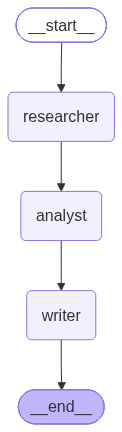

In [47]:
# Build the research -> analysis -> writing workflow.
workflow = StateGraph(AgentState)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

workflow.set_entry_point("researcher")
workflow.add_edge("researcher", "analyst")
workflow.add_edge("analyst", "writer")
workflow.add_edge("writer", END)
final_workflow = workflow.compile()

final_workflow


In [48]:
result = final_workflow.invoke(
    {"messages": [{"role": "user", "content": "Research about the latest discoveries in Ancient Bengal"}]},
    config={"callbacks": [langsmith_tracer]} if langsmith_tracer else {},
)
if langsmith_tracer:
    langsmith_tracer.wait_for_futures()
import pprint
pprint.pprint(result)  # Use pretty print

{'messages': [HumanMessage(content='Research about the latest discoveries in Ancient Bengal', additional_kwargs={}, response_metadata={}, id='7ee63dcc-bb0f-4c0d-a851-24e93edf2ad6'),
              HumanMessage(content='Research results for the request:\n[{\'url\': \'https://www.academia.edu/126443938/Two_Recently_Discovered_Inscriptions_from_West_Bengal\', \'title\': \'Two Recently Discovered Inscriptions from West Bengal\', \'content\': "Continuous discoveries of primary sources have been characterising epigraphic researches in Bengal for nearly last five decades. The present work is based on yet another notice of a broken but mostly unspoilt copperplate preserved in a private collection in Kolkata dated in the reign of the tenth-century Pāla king Rājyapāla, son and successor of Nārāyaṇapāla. The only published copperplate of this king, preserved in the Bharat Kala Bhavan of the Banaras Hindu University, records grant of land [...] From all of undivided Bengal, less than two dozen copp

In [77]:
# ================================================================
# State Definition
# Define the state structure for the multi-agent system.
# ================================================================

class SupervisorState(MessagesState):
    """State for multi-agent system."""
    next_agent: str = ""
    research_data: str = ""
    analysis: str = ""
    final_report: str = ""
    research_completed: bool = False
    analysis_completed: bool = False
    report_completed: bool = False
    current_task: str = ""

In [50]:
from langchain_core.prompts import ChatPromptTemplate

def create_supervisor_chain():
    """Creates the supervisor chain for the multi-agent system."""
    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are the supervisor managing a team of agents:
1. Researcher - Gathers information and conducts research.
2. Analyst   - Analyzes the gathered information and provides insights.
3. Writer    - Documents the findings and insights provided by the team.

Based on the current state and conversation, decide which agent should take the next action.
If the task is completed, respond with 'DONE'.

Current state:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}

Respond with ONLY the agent name (researcher, analyst, writer) or 'DONE' if the task is completed.
"""),
        ("human", "{task}"),
    ])
    return supervisor_prompt | llm

In [80]:
def supervisor_agent(state: SupervisorState) -> dict:
    """Select the next worker from explicit completion flags."""
    messages = state.get("messages", [])
    task = ""
    for message in messages:
        content = message.get("content", "") if isinstance(message, dict) else getattr(message, "content", "")
        if content:
            task = str(content)
            break

    if not state.get("research_completed", False):
        next_agent = "researcher"
    elif not state.get("analysis_completed", False):
        next_agent = "analyst"
    elif not state.get("report_completed", False):
        next_agent = "writer"
    else:
        next_agent = "end"

    return {
        "next_agent": next_agent,
        "current_task": task,
        "decision": next_agent,
    }


In [76]:
# Create writer agent

def writer_agent(state: AgentState) -> dict:
    """Generate a grounded final report from research evidence and analyst findings."""
    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    current_request = state.get("current_task", "")
    writer_prompt = f"""Write the final answer for the user's request.

Use only the research evidence and analysis below. Do not invent facts. Clearly label uncertainty or missing evidence.
Provide a concise conclusion followed by useful supporting details and source caveats.

User request:
{current_request}

Research evidence:
{research_data}

Analyst assessment:
{analysis}
"""
    response = llm.invoke([
        SystemMessage(content="You are a careful technical writer producing evidence-grounded reports."),
        HumanMessage(content=writer_prompt),
    ])
    return {
        "messages": [response],
        "next_agent": "end",
        "final_report": response.content,
        "report_completed": True,
    }


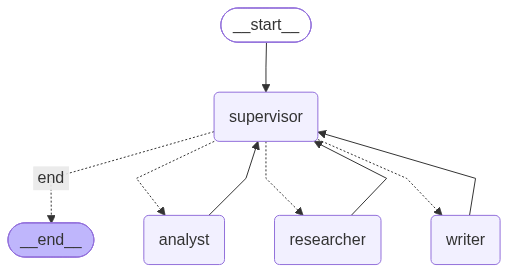

In [81]:
# Supervisor workflow graph
supervisor_workflow = StateGraph(SupervisorState)
supervisor_workflow.add_node("supervisor", supervisor_agent)
supervisor_workflow.add_node("researcher", researcher_agent)
supervisor_workflow.add_node("analyst", analyst_agent)
supervisor_workflow.add_node("writer", writer_agent)
supervisor_workflow.set_entry_point("supervisor")


def route_from_supervisor(state: SupervisorState):
    return state.get("next_agent", "end")


supervisor_workflow.add_conditional_edges(
    "supervisor",
    route_from_supervisor,
    {
        "researcher": "researcher",
        "analyst": "analyst",
        "writer": "writer",
        "end": END,
    },
)
supervisor_workflow.add_edge("researcher", "supervisor")
supervisor_workflow.add_edge("analyst", "supervisor")
supervisor_workflow.add_edge("writer", "supervisor")
supervisor_graph = supervisor_workflow.compile()
supervisor_graph


In [82]:
# ================================================================
# Run the supervisor workflow
# ================================================================
result = supervisor_graph.invoke(
    {"messages": [{"role": "user", "content": "Research about the latest discoveries in Ancient Bengal"}]},
    config={"callbacks": [langsmith_tracer]} if langsmith_tracer else {},
)
if langsmith_tracer:
    langsmith_tracer.wait_for_futures()

import pprint

pprint.pprint(result)

{'analysis': '**Strongly Supported Findings:**\n'
             '\n'
             '1. **Two Recently Discovered Inscriptions from West Bengal:**\n'
             '   - Continuous discoveries of primary sources have '
             'characterized epigraphic research in Bengal for nearly five '
             'decades.\n'
             '   - A copperplate dated to the reign of the tenth-century Pāla '
             'king Rājyapāla, son and successor of Nārāyaṇapāla, has been '
             'preserved in a private collection in Kolkata.\n'
             '   - The first new copperplate is dated to year 159 of the Gupta '
             'era (478 CE) and issued during the reign of Budhagupta.\n'
             '   - The second new copperplate is dated to the year 5 of a '
             'previously unknown king named Pradyumnabandhu.\n'
             '\n'
             '2. **Ancient civilisation unearthed in West Bengal:**\n'
             '   - Archaeological findings near Clive House in Dum Dum have '
   

In [64]:
def router(state: SupervisorState) -> Literal["supervisor", "researcher", "analyst", "writer", "__end__"]:
    """Route according to the supervisor's decision."""
    next_agent = state.get("next_agent", "supervisor")
    if next_agent == "end" or state.get("task_complete", False):
        return END
    if next_agent in ["supervisor", "researcher", "analyst", "writer"]:
        return next_agent
    return "supervisor"

In [87]:
# Create workflow

workflow = StateGraph(SupervisorState)

# Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)


# Set entrypoint
workflow.set_entry_point("supervisor")

# Add routing
for node in ["supervisor", "researcher", "analyst", "writer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            END: END,
        }
    )


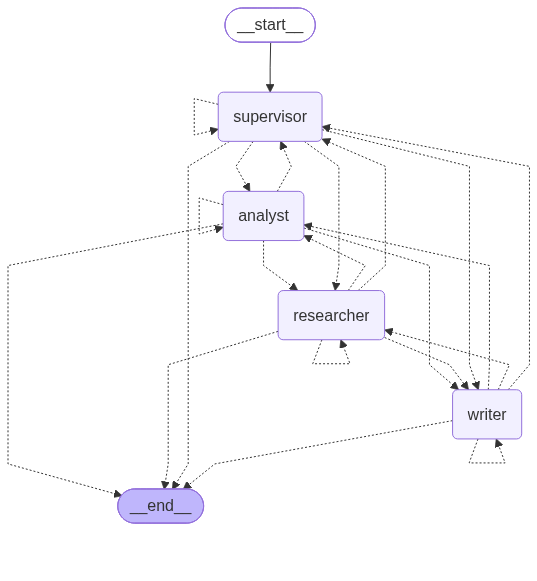

In [88]:
graph=workflow.compile()
graph

In [89]:
# Run the workflow graph with the expected state shape.
result = graph.invoke(
    {
        "messages": [
            HumanMessage(content="What are the oldest living creatures?")
        ]
    },
    config={"callbacks": [langsmith_tracer]} if langsmith_tracer else {},
)

if langsmith_tracer:
    langsmith_tracer.wait_for_futures()

print(result.get("final_report") or result["messages"][-1].content)


The conclusion is that the ten longest-living creatures identified in the research evidence are a jellyfish, an Antarctic sponge, a Seychelles giant tortoise, a radiated tortoise, an Aldabra giant tortoise, a gorilla, a Laysan albatross, a Sumatran orangutan, a glass sponge, and a blue and yellow macaw. The supporting details are that jellyfish can live for thousands of years due to their ability to regenerate cells, Antarctic sponges can live up to 10,000 years, Seychelles giant tortoises can live for over 190 years, radiated tortoises have been verified to live up to 188 years, Aldabra giant tortoises can live for over 255 years, gorillas can live up to 68 years, Laysan albatrosses can live for over 74 years, Sumatran orangutans can live for over 64 years, glass sponges can live for over 10,000 years, and blue and yellow macaws can live for over 100 years. The source caveats are that these lifespans are estimates and may not be accurate, and the oldest living creature is a jellyfish,